# Seizure distribution (TMEV)
This notebook reproduces Fig. 1C of the publication DOI: 10.1126/scitranslmed.adv3260

In [1]:
import sys
import os
notebook_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))  # Add the project root directory to the path

import h5py
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import env_reader
from seizure_distribution import *


In [2]:
save_results = False

In [3]:
env_dict = env_reader.read_env()
output_dir = None
if save_results:
    output_dir = env_dict["OUTPUT_FOLDER"]
    assert os.path.exists(output_dir), f"Output directory does not exist: {output_dir}"

In [4]:
fpath_sz_data = os.path.join(env_dict["DATA_FOLDER"], "Seizure_distribution", "tmev_seizures.hdf5")
assert os.path.exists(fpath_sz_data), f"File not found: {fpath_sz_data}"

In [5]:
sz_times_dict_filtered, n_max_sz, n_mice = open_sz_distribution_file(fpath_sz_data)

In [10]:
# get short format df: each column is a mouse ID
df_sz_times_short = sz_distribution_df_short(sz_times_dict_filtered, n_max_sz, n_mice)

In [7]:
df_sz_times_long = sz_distribution_df_short_to_long(df_sz_times_short)

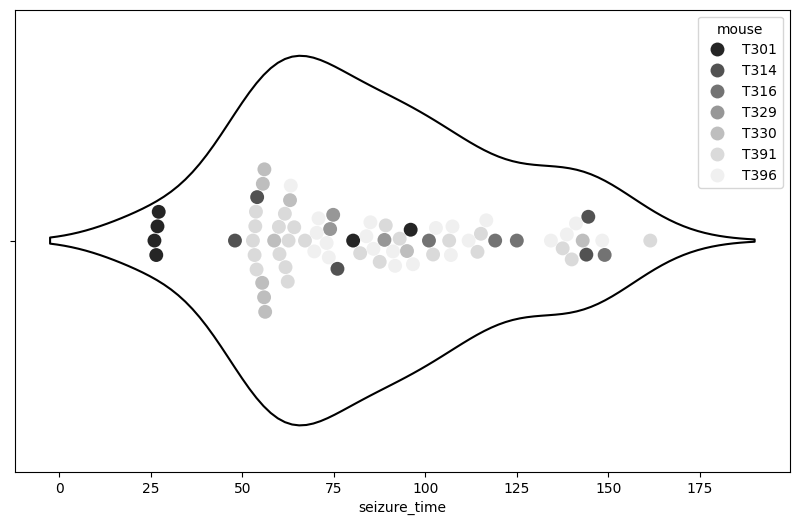

In [8]:
# make combined kde plot with stripplot in seaborn, x axis is time.
fig, axs = plt.subplots(1, 1, figsize=(10, 6))
sns.violinplot(data=df_sz_times_long, x='seizure_time', inner=None, fill=False, color="black", ax=axs)
# add swarmplot with shades of grey for each mouse, 
sns.swarmplot(data=df_sz_times_long, x='seizure_time', hue='mouse', s=10, palette="Greys_r", ax=axs)
plt.show()


In [ ]:
if save_results:
    fpath_output = os.path.join(output_dir, "seizure_times_sorted.xlsx")
    assert not os.path.exists(fpath_output), f"Output file already exists: {fpath_output}"
    print(f"Saving to {fpath_output}")
    df_sz_times_short.to_excel(fpath_output, index=False)